## Exploring and Preprocessing Mental Health Data

### Schritt 1: Initialisierung und Laden der Daten
- Importiere die erforderlichen Bibliotheken und lade die Trainings- und Testdatensätze.
- Verarbeite beide Datensätze gleichzeitig, damit das endgültige Modell bei der Vorhersage genau dieselben Merkmalsstrukturen erhält.

In [30]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Load datasets
train_dataset = pd.read_csv("train.csv")
test_dataset = pd.read_csv("test.csv")

display(train_dataset.head())

,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,Aaradhya,Female,49.0,Ludhiana,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,1,Vivan,Male,26.0,Varanasi,Working Professional,Teacher,NaN,4.0,NaN,NaN,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1
2,2,Yuvraj,Male,33.0,Visakhapatnam,Student,NaN,5.0,NaN,8.97,2.0,NaN,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
3,3,Yuvraj,Male,22.0,Mumbai,Working Professional,Teacher,NaN,5.0,NaN,NaN,1.0,Less than 5 hours,Moderate,BBA,Yes,10.0,1.0,Yes,1
4,4,Rhea,Female,30.0,Kanpur,Working Professional,Business Analyst,NaN,1.0,NaN,NaN,1.0,5-6 hours,Unhealthy,BBA,Yes,9.0,4.0,Yes,0


In [34]:
print(train_dataset['Dietary Habits'].unique())
print(train_dataset['Sleep Duration'].unique())


['Healthy' 'Unhealthy' 'Moderate' 'Yes' 'Pratham' 'BSc' 'Gender' '3'
 'More Healthy' 'Less than Healthy' 'Mihir' '1.0' 'Hormonal' 'Electrician'
 nan 'No Healthy' 'Less Healthy' 'M.Tech' 'Vegas' 'No' 'Male' 'Indoor'
 'Class 12' '2']
['More than 8 hours' 'Less than 5 hours' '5-6 hours' '7-8 hours'
 'Sleep_Duration' '1-2 hours' '6-8 hours' '4-6 hours' '6-7 hours'
 '10-11 hours' '8-9 hours' '40-45 hours' '9-11 hours' '2-3 hours'
 '3-4 hours' 'Moderate' '55-66 hours' '4-5 hours' '9-6 hours' '1-3 hours'
 'Indore' '45' '1-6 hours' '35-36 hours' '8 hours' 'No' '10-6 hours'
 'than 5 hours' '49 hours' 'Unhealthy' 'Work_Study_Hours' '3-6 hours'
 '45-48 hours' '9-5' 'Pune' '9-5 hours']


### Schritt 2: Feature Engineering & Datenbereinigung
Es gibt mehrere Spalten, die bereinigt und zusammengefasst werden müssen. Um zu vermeiden, denselben Code zweimal zu schreiben (einmal für das Training, einmal für den Test), erstellen wir eine einzige Funktion `preprocess_features`, die die gesamte Logik abdeckt:

1. **Kombinierter Druck:** `Academic Pressure` und `Work Pressure` schließen sich gegenseitig aus => zusammenführen
2. **Kombinierte Zufriedenheit:** Ebenso werden wir `Study Satisfaction` und `Job Satisfaction` zusammenführen.
3. **Studentenstatus:** Umwandlung von `Working Professional or Student` in eine binäre Spalte `is_student`.
4. **Gesundheitsindex:** Zuordnung von `Dietary Habits` und `Sleep Duration` zu numerischen Werten und Zusammenführung zu einem einzigen Index.
5. **Umgang mit fehlenden Werten:** Auffüllen von NaNs in numerischen Spalten (wie CGPA und Alter) und kategorialen Spalten (wie Beruf und Abschluss).
6. **Entfernen unnötiger Daten:** Wir entfernen `Name`, da dieser keinen prädiktiven Wert hat.


In [35]:
def preprocess_features(df):
    df = df.copy()
    
    # 1. Kombinierter Druck
    df['Academic Pressure'] = df['Academic Pressure'].fillna(0)
    df['Work Pressure'] = df['Work Pressure'].fillna(0)
    df['Combined Pressure'] = df['Academic Pressure'] + df['Work Pressure']
    df.drop(['Academic Pressure', 'Work Pressure'], axis=1, inplace=True)
    
    # 2. Kombinierter Zufriedenheit
    df['Study Satisfaction'] = df['Study Satisfaction'].fillna(0)
    df['Job Satisfaction'] = df['Job Satisfaction'].fillna(0)
    df['Combined Satisfaction'] = df['Study Satisfaction'] + df['Job Satisfaction']
    df.drop(['Study Satisfaction', 'Job Satisfaction'], axis=1, inplace=True)
    
    # 3. Studentenstatus
    df['is_student'] = (df['Working Professional or Student'] == 'Student').astype(int)
    df.drop('Working Professional or Student', axis=1, inplace=True)
    
    # 4. Gesundheitsindex
    diet_map = {'Healthy': 3, 'Moderate': 2, 'Unhealthy': 1}
    sleep_map = {'More than 8 hours': 4, '7-8 hours': 3, '5-6 hours': 2, 'Less than 5 hours': 1}
    df['Dietary Habits'] = df['Dietary Habits'].fillna('Moderate') # filled NaN vals with the middle nr from map
    df['Sleep Duration'] = df['Sleep Duration'].fillna('7-8 hours') # same here
    df['Health_Index'] = df['Dietary Habits'].map(diet_map) + df['Sleep Duration'].map(sleep_map)
    df['Health_Index'] = df['Health_Index'].fillna(df['Health_Index'].median())  # ADD THIS
    df.drop(['Dietary Habits', 'Sleep Duration'], axis=1, inplace=True)
    
    # 5. Umgang mit fehlenden Werten
    df['CGPA'] = df['CGPA'].fillna(0)
    df['Age'] = df['Age'].fillna(df['Age'].median())                          # NEW
    df['Work/Study Hours'] = df['Work/Study Hours'].fillna(df['Work/Study Hours'].median())  # NEW
    df['Financial Stress'] = df['Financial Stress'].fillna(0)                 # NEW
    df['Profession'] = df['Profession'].fillna('Unknown')
    df['Degree'] = df['Degree'].fillna('Unknown')
    df['City'] = df['City'].fillna('Unknown')
    df['Gender'] = df['Gender'].fillna('Unknown')                             # NEW
    df['Have you ever had suicidal thoughts ?'] = df['Have you ever had suicidal thoughts ?'].fillna('Unknown')  # NEW
    df['Family History of Mental Illness'] = df['Family History of Mental Illness'].fillna('Unknown') #NEW
    # 6. Entfernen unnötiger daten (Name)
    df.drop(['Name'], axis=1, inplace=True)
    
    return df

X_train_full = preprocess_features(train_dataset)
X_test = preprocess_features(test_dataset)

y_train = X_train_full['Depression']    # target vector
X_train = X_train_full.drop(['Depression'], axis=1)    # feature matrix

display(X_train.head())

,id,Gender,Age,City,Profession,CGPA,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Combined Pressure,Combined Satisfaction,is_student,Health_Index
0,0,Female,49.0,Ludhiana,Chef,0.00,BHM,No,1.0,2.0,No,5.0,2.0,0,7.0
1,1,Male,26.0,Varanasi,Teacher,0.00,LLB,Yes,7.0,3.0,No,4.0,3.0,0,2.0
2,2,Male,33.0,Visakhapatnam,Unknown,8.97,B.Pharm,Yes,3.0,1.0,No,5.0,2.0,1,5.0
3,3,Male,22.0,Mumbai,Teacher,0.00,BBA,Yes,10.0,1.0,Yes,5.0,1.0,0,3.0
4,4,Female,30.0,Kanpur,Business Analyst,0.00,BBA,Yes,9.0,4.0,Yes,1.0,1.0,0,3.0


### Schritt 3: Kodierung kategorialer Variablen
- Umwandlung der verbleibenden Textspalten (`Gender`, `City`, `Profession`, `Degree`, `Have you ever had suicidal thoughts ?`, `Family History of Mental Illness`) in Zahlen. 
- Dazu werden `ColumnTransformer` und `OneHotEncoder` aus Scikit-Learn verwendet, um dies dynamisch durchzuführen.
- Skalierung der numerischen Merkmale, damit sie auf derselben Skala liegen.

In [36]:
categorical_cols = ['Gender', 'City', 'Profession', 'Degree', 
                    'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']

numerical_cols = ['Age', 'CGPA', 'Work/Study Hours', 'Financial Stress', 
                  'Combined Pressure', 'Combined Satisfaction', 'is_student', 'Health_Index']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ],
    remainder='passthrough'
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(X_train)

            id  Gender   Age           City         Profession  CGPA  \
0            0  Female  49.0       Ludhiana               Chef  0.00   
1            1    Male  26.0       Varanasi            Teacher  0.00   
2            2    Male  33.0  Visakhapatnam            Unknown  8.97   
3            3    Male  22.0         Mumbai            Teacher  0.00   
4            4  Female  30.0         Kanpur   Business Analyst  0.00   
...        ...     ...   ...            ...                ...   ...   
140695  140695  Female  18.0      Ahmedabad            Unknown  0.00   
140696  140696  Female  41.0      Hyderabad     Content Writer  0.00   
140697  140697  Female  24.0        Kolkata  Marketing Manager  0.00   
140698  140698  Female  49.0       Srinagar            Plumber  0.00   
140699  140699    Male  27.0          Patna            Unknown  9.24   

          Degree Have you ever had suicidal thoughts ?  Work/Study Hours  \
0            BHM                                    No     

In [37]:
print(X_train.isnull().sum())
print(X_test.isnull().sum())

id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
CGPA                                     0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
Combined Pressure                        0
Combined Satisfaction                    0
is_student                               0
Health_Index                             0
dtype: int64
id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
CGPA                                     0
Degree                                   0
Have you ever had suicidal thoughts ?    

## Splitting Training Data 
75% **training** - 25% **test** Data with **cross-validation**
every teammember has to have the same split, so that the results from the models are comparable  

In [38]:
from sklearn.model_selection import train_test_split
print(X_train_processed.shape)
print(y_train.shape)
# Everyone uses this exact split
(X_tr, X_val, y_tr, y_val) = train_test_split( X_train_processed, y_train,
                                               test_size = 0.25,
                                               random_state = 42,
                                               stratify = y_train
    
                                                       
)
print(X_tr.shape)
print(y_tr.shape)
print(X_val.shape)
print(y_val.shape)

(140700, 294)
(140700,)
(105525, 294)
(105525,)
(35175, 294)
(35175,)


## KNN
-1.create:am creat modelul
-2.train:l-am antrenat cu fit.(X_tr, y_tr)
-3.predict: folosesc modelul ca sa prezica pe X_val cu .predict()
-4.evaluate:vad cat de bine a prezis - cassification_report cu accuracy, precision,recall,F1.

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
K=3 → accuracy: 0.8162
              precision    recall  f1-score   support

           0       0.84      0.96      0.90     28783
           1       0.48      0.18      0.26      6392

    accuracy                           0.82     35175
   macro avg       0.66      0.57      0.58     35175
weighted avg       0.78      0.82      0.78     35175

K=5 → accuracy: 0.8136
              precision    recall  f1-score   support

           0       0.83      0.98      0.90     28783
           1       0.43      0.08      0.14      6392

    accuracy                           0.81     35175
   macro avg       0.63      0.53      0.52     35175
weighted avg       0.75      0.81      0.76     35175

K=7 → accuracy: 0.8125
              precision    recall  f1-score   support

           0       0.82      0.98      0.90     28783
           1  

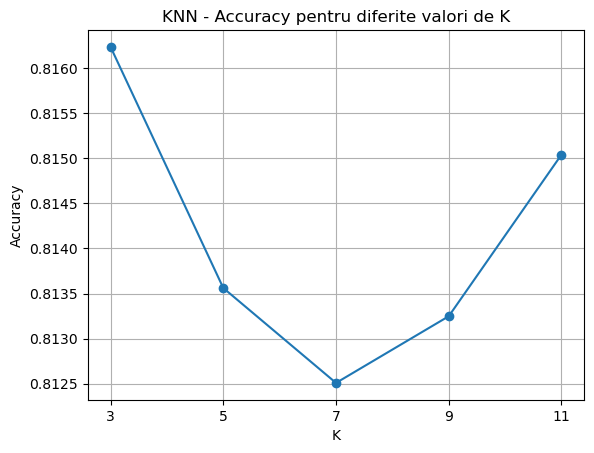

In [61]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

k_values = [3, 5, 7, 9, 11]
accuracies = []
for k in k_values:
    knn = KNeighborsClassifier(k)
    knn.fit(X_tr, y_tr)
    y_predicted = knn.predict(X_val)
    accuracies.append(accuracy_score(y_val, y_predicted))
    print(f"K={k} → accuracy: {accuracy_score(y_val, y_predicted):.4f}")
    print(classification_report(y_val, y_predicted))

# Plot după buclă
plt.plot(k_values, accuracies, marker='o')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.title('KNN - Accuracy pentru diferite valori de K')
plt.xticks(k_values)
plt.grid(True)
plt.show()



## Decision Tree


--- max_depth=3 ---
              precision    recall  f1-score   support

           0       0.93      0.97      0.95     28783
           1       0.82      0.67      0.74      6392

    accuracy                           0.91     35175
   macro avg       0.87      0.82      0.84     35175
weighted avg       0.91      0.91      0.91     35175


--- max_depth=5 ---
              precision    recall  f1-score   support

           0       0.95      0.96      0.95     28783
           1       0.81      0.76      0.79      6392

    accuracy                           0.92     35175
   macro avg       0.88      0.86      0.87     35175
weighted avg       0.92      0.92      0.92     35175


--- max_depth=7 ---
              precision    recall  f1-score   support

           0       0.95      0.96      0.96     28783
           1       0.82      0.78      0.80      6392

    accuracy                           0.93     35175
   macro avg       0.88      0.87      0.88     35175
weighted av

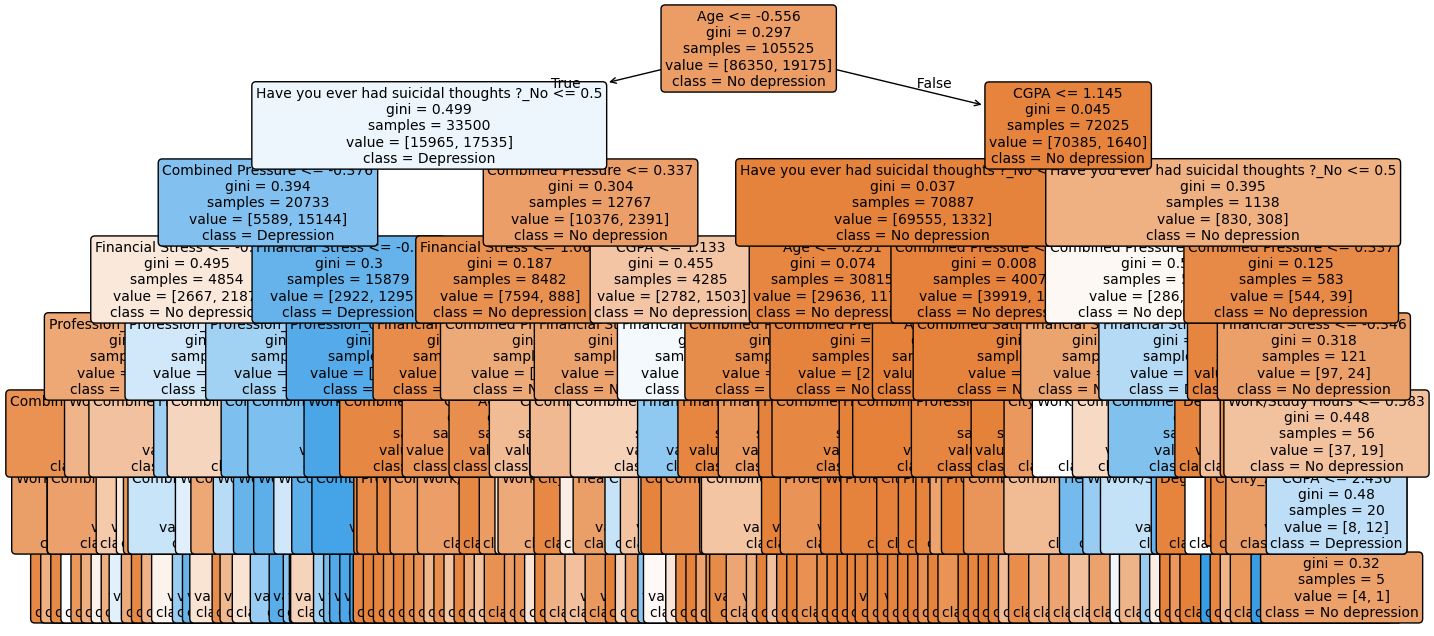

In [62]:
from sklearn.tree import DecisionTreeClassifier
for depth in [3, 5, 7, 10]:
    decision_tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    decision_tree.fit(X_tr, y_tr)
    y_predicted = decision_tree.predict(X_val)
    print(f"\n--- max_depth={depth} ---")
    print(classification_report(y_val, y_predicted))

num_cols_names = numerical_cols
cat_cols_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist()
all_cols = num_cols_names + cat_cols_names + ['id']

decision_tree_best=DecisionTreeClassifier(max_depth=7, random_state=42)
decision_tree_best.fit(X_tr, y_tr)

from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8)) 
tree.plot_tree(decision_tree_best,
    feature_names=all_cols,  
    class_names=["No depression", "Depression"],       
    filled=True,                              
    rounded=True,                             
    fontsize=10)
plt.show()

## RandomForestClassifier with default params:

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report 
# Model 1 Diana
rf = RandomForestClassifier()
rf.fit(X_tr, y_tr)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


**Accuracy**

In [40]:
rf.score(X_val, y_val)

0.9334186211798152

**comparing the oredicted values from test set to the actual target values**

In [41]:
y_pred = rf.predict(X_val)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96     28783
           1       0.85      0.77      0.81      6392

    accuracy                           0.93     35175
   macro avg       0.90      0.87      0.88     35175
weighted avg       0.93      0.93      0.93     35175



## Balancing Random Forest Classifier with weights
cause I can tweak directly in tne Classifier param list, instead of using oversampling with SMOTE
**main reason** 
the recall score for classifying depression as true is only 0.77 which means there are 0.33 false negatives, that is more valuable to get right than the negatives.

In [43]:
rf_balanced = RandomForestClassifier(class_weight = 'balanced')
rf_balanced.fit(X_tr, y_tr)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [45]:
rf_balanced.score(X_val, y_val)

0.9326510305614784

In [46]:
y_pred_balanced = rf_balanced.predict(X_val)
print(classification_report(y_val, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96     28783
           1       0.85      0.77      0.81      6392

    accuracy                           0.93     35175
   macro avg       0.90      0.87      0.88     35175
weighted avg       0.93      0.93      0.93     35175



## XGBoost Classifier 

In [49]:
from xgboost import XGBClassifier

In [48]:
!pip install xgboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 786.7 kB/s  0:00:032.0 kB/s eta 0:00:011


In [50]:
xgb = XGBClassifier(random_state = 42)
xgb.fit(X_tr, y_tr)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [51]:
xgb.score(X_val, y_val)

0.9364321250888415

In [52]:
y_pred_xgb = xgb.predict(X_val)
print(classification_report(y_val, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96     28783
           1       0.83      0.81      0.82      6392

    accuracy                           0.94     35175
   macro avg       0.90      0.89      0.89     35175
weighted avg       0.94      0.94      0.94     35175



# Hyperparameter Tuning on XGBClassifier


In [54]:
from sklearn.model_selection import RandomizedSearchCV

In [55]:
xgb_tuned = XGBClassifier()
param_grid = {
    'n_estimators' : [100, 200, 300],
    'max_depth' : [3, 5 , 7],
    'learning_rate' : [0.05, 0.1, 0.2],
    'subsample' : [0.7, 0.8, 1.0],
    'scale_pos_weight' : [1, 3, 4.5]
}
xgb_search = RandomizedSearchCV(
    xgb_tuned,
    param_grid,
    cv = 5,
    scoring = 'f1',
    n_iter = 20, 
    n_jobs = -1,
    random_state = 42
)


In [56]:
xgb_search.fit(X_tr, y_tr)

,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'learning_rate': [0.05, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], 'scale_pos_weight': [1, 3, ...], ...}"
,n_iter,20
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [57]:
xgb_search.best_params_


{'subsample': 0.7,
 'scale_pos_weight': 1,
 'n_estimators': 300,
 'max_depth': 5,
 'learning_rate': 0.05}

In [58]:
xgb_search.best_score_ #best f1 score 

np.float64(0.8291311067550324)

In [60]:
xgb_search.best_estimator_.score(X_val, y_val) #accuracy

0.9374271499644634

In [59]:
y_pred_xgb_tuned = xgb_search.best_estimator_.predict(X_val)
print(classification_report(y_val, y_pred_xgb_tuned))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96     28783
           1       0.84      0.81      0.83      6392

    accuracy                           0.94     35175
   macro avg       0.90      0.89      0.89     35175
weighted avg       0.94      0.94      0.94     35175



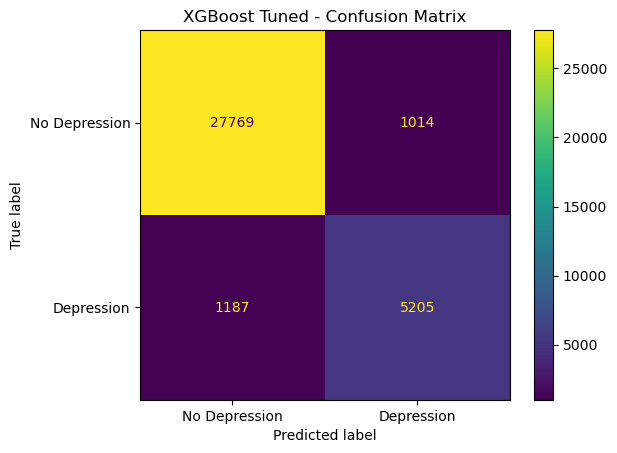

In [63]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_xgb_tuned, display_labels=['No Depression', 'Depression'])
plt.title('XGBoost Tuned - Confusion Matrix')
plt.show()


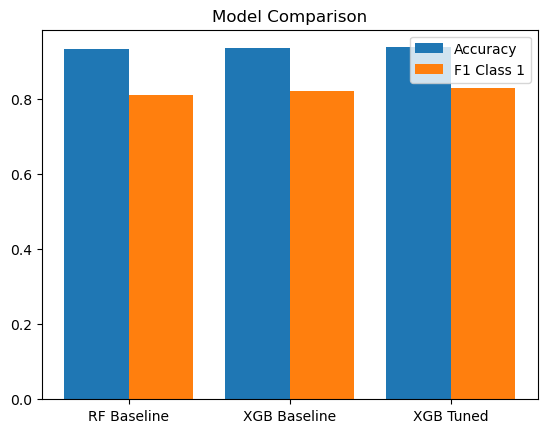

In [71]:
models = ['RF Baseline', 'XGB Baseline', 'XGB Tuned']
accuracies = [rf.score(X_val, y_val), xgb.score(X_val, y_val), xgb_search.best_estimator_.score(X_val, y_val)]
f1_scores = [0.81, 0.82, 0.83]  # class 1 F1 from reports

x = np.arange(len(models))
plt.bar(x - 0.2, accuracies, 0.4, label='Accuracy')
plt.bar(x + 0.2, f1_scores, 0.4, label='F1 Class 1')
plt.xticks(x, models)
plt.legend()
plt.title('Model Comparison')
plt.show()
